In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from IPython.display import Markdown, display
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
T100path = "/content/drive/My Drive/DAT490/Datasets/T100-Merged.csv"
F41path  = "/content/drive/My Drive/DAT490/Datasets/F41_1.2-Merged.csv"
OTPpath  = "/content/drive/My Drive/DAT490/Datasets/OTP_Kaggle.csv"

T100    = pd.read_csv(T100path, low_memory=False)
F41     = pd.read_csv(F41path)
otp_raw = pd.read_csv(OTPpath)

print("T100 shape:", T100.shape)
print("F41 shape: ", F41.shape)
print("OTP shape: ", otp_raw.shape)
print("\nOTP columns:", otp_raw.columns.tolist())
print("OTP years:  ", sorted(otp_raw['year'].unique()))

T100 shape: (2193983, 38)
F41 shape:  (3678, 53)
OTP shape:  (398233, 21)

OTP columns: ['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay']
OTP years:   [np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [ ]:
t100 = T100.copy()
f41  = F41.copy()

t100_numeric_cols = [
    'Quarterly Net Income','PASSENGERS','FREIGHT','MAIL','DISTANCE',
    'AIRLINE_ID','ORIGIN_AIRPORT_ID','ORIGIN_CITY_MARKET_ID',
    'DEST_AIRPORT_ID','DEST_CITY_MARKET_ID','YEAR','QUARTER',
    'MONTH','DISTANCE_GROUP'
]
for col in t100_numeric_cols:
    if col in t100.columns:
        t100[col] = pd.to_numeric(t100[col], errors='coerce')

f41_numeric_cols = [
    'NET_INCOME','OP_PROFIT_LOSS','TRANS_REV_PAX','MAIL',
    'TOTAL_PROPERTY','PROP_FREIGHT','PROP_BAG','TOTAL_CHARTER',
    'CHARTER_PAX','CHARTER_PROP','TOTAL_MISC_REV','RES_CANCEL_FEES',
    'MISC_OP_REV','PUB_SVC_REVENUE','TRANS_REVENUE','OP_REVENUES',
    'FLYING_OPS','MAINTENANCE','PAX_SERVICE','AIRCFT_SERVICES',
    'PROMOTION_SALES','GENERAL_ADMIN','GENERAL_SERVICES','DEPREC_AMORT',
    'TRANS_EXPENSES','OP_EXPENSES','INTEREST_LONG_DEBT','INTEREST_EXP_OTH',
    'FOREIGN_EX_GAINS','CAP_GAINS_PROP','CAP_GAINS_OTHER','OTHER_INCOME_NET',
    'NON_OP_INCOME','INCOME_PRE_TAX','INCOME_TAX','INCOME_BEFORE_OTH',
    'DISCONT_OPS','EXTRA_ITEMS','INCOME_TAX_EXTRA','INCOME_TAX_CREDITS',
    'ACCTG_CHANGES','AIRLINE_ID','YEAR','QUARTER'
]
for col in f41_numeric_cols:
    if col in f41.columns:
        f41[col] = pd.to_numeric(f41[col], errors='coerce')

print("T100 missing net income:", t100['Quarterly Net Income'].isna().sum())
print("F41 missing NET_INCOME: ", f41['NET_INCOME'].isna().sum())

T100 missing net income: 369002
F41 missing NET_INCOME:  0


In [ ]:
t100_agg = (
    t100.groupby('Match Key Carrier-Quarter-Year')
    .agg({
        'Quarterly Net Income':     'first',
        'PASSENGERS':               'sum',
        'FREIGHT':                  'sum',
        'MAIL':                     'sum',
        'DISTANCE':                 'sum',
        'AIRLINE_ID':               'first',
        'UNIQUE_CARRIER':           'first',
        'UNIQUE_CARRIER_NAME':      'first',
        'UNIQUE_CARRIER_ENTITY':    'first',
        'REGION':                   'first',
        'CARRIER':                  'first',
        'CARRIER_NAME':             'first',
        'CARRIER_GROUP':            'first',
        'CARRIER_GROUP_NEW':        'first',
        'YEAR':                     'first',
        'QUARTER':                  'first',
        'MONTH':                    'nunique',
        'DISTANCE_GROUP':           'mean',
        'ORIGIN_AIRPORT_ID':        'nunique',
        'DEST_AIRPORT_ID':          'nunique',
        'ORIGIN_CITY_MARKET_ID':    'nunique',
        'DEST_CITY_MARKET_ID':      'nunique'
    })
    .reset_index()
)

print("t100_agg shape:", t100_agg.shape)
t100_agg.head()

t100_agg shape: (4440, 23)


,Match Key Carrier-Quarter-Year,Quarterly Net Income,PASSENGERS,FREIGHT,MAIL,DISTANCE,AIRLINE_ID,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,...,CARRIER_GROUP,CARRIER_GROUP_NEW,YEAR,QUARTER,MONTH,DISTANCE_GROUP,ORIGIN_AIRPORT_ID,DEST_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,DEST_CITY_MARKET_ID
0,02Q20224,NaN,51,0,0,2606,21040.0,02Q,Titan Airways,71004,...,0,0.0,2022,4,1,3.0,2,2,2,2
1,02Q20231,NaN,54,0,0,1425,21040.0,02Q,Titan Airways,71004,...,0,0.0,2023,1,1,3.0,1,1,1,1
2,02Q20234,NaN,7,0,0,1402,21040.0,02Q,Titan Airways,71004,...,0,0.0,2023,4,1,3.0,1,1,1,1
3,02Q20241,NaN,44,0,0,3928,21040.0,02Q,Titan Airways,71004,...,0,0.0,2024,1,1,8.0,1,1,1,1
4,02Q20242,NaN,43,0,0,1446,21040.0,02Q,Titan Airways,71004,...,0,0.0,2024,2,2,2.0,2,2,2,2


In [ ]:
t100['route_key'] = (
    t100['ORIGIN_AIRPORT_ID'].astype(str) + "_" +
    t100['DEST_AIRPORT_ID'].astype(str)
)
route_counts = (
    t100.groupby('Match Key Carrier-Quarter-Year')['route_key']
    .nunique()
    .reset_index(name='route_count')
)
t100_agg = t100_agg.merge(
    route_counts,
    on='Match Key Carrier-Quarter-Year',
    how='left'
)
print("t100_agg shape after route merge:", t100_agg.shape)

t100_agg shape after route merge: (4440, 24)


In [ ]:
if 'MAIL' in f41.columns:
    f41 = f41.rename(columns={'MAIL': 'F41_MAIL'})

f41_agg = (
    f41.groupby('Match Key Carrier-Quarter-Year')
    .agg({
        'NET_INCOME':           'first',
        'OP_PROFIT_LOSS':       'first',
        'TRANS_REV_PAX':        'first',
        'F41_MAIL':             'first',
        'TOTAL_PROPERTY':       'first',
        'PROP_FREIGHT':         'first',
        'PROP_BAG':             'first',
        'TOTAL_CHARTER':        'first',
        'CHARTER_PAX':          'first',
        'CHARTER_PROP':         'first',
        'TOTAL_MISC_REV':       'first',
        'RES_CANCEL_FEES':      'first',
        'MISC_OP_REV':          'first',
        'PUB_SVC_REVENUE':      'first',
        'TRANS_REVENUE':        'first',
        'OP_REVENUES':          'first',
        'FLYING_OPS':           'first',
        'MAINTENANCE':          'first',
        'PAX_SERVICE':          'first',
        'AIRCFT_SERVICES':      'first',
        'PROMOTION_SALES':      'first',
        'GENERAL_ADMIN':        'first',
        'GENERAL_SERVICES':     'first',
        'DEPREC_AMORT':         'first',
        'TRANS_EXPENSES':       'first',
        'OP_EXPENSES':          'first',
        'INTEREST_LONG_DEBT':   'first',
        'INTEREST_EXP_OTH':     'first',
        'FOREIGN_EX_GAINS':     'first',
        'CAP_GAINS_PROP':       'first',
        'CAP_GAINS_OTHER':      'first',
        'OTHER_INCOME_NET':     'first',
        'NON_OP_INCOME':        'first',
        'INCOME_PRE_TAX':       'first',
        'INCOME_TAX':           'first',
        'INCOME_BEFORE_OTH':    'first',
        'DISCONT_OPS':          'first',
        'EXTRA_ITEMS':          'first',
        'INCOME_TAX_EXTRA':     'first',
        'INCOME_TAX_CREDITS':   'first',
        'ACCTG_CHANGES':        'first',
        'AIRLINE_ID':           'first',
        'UNIQUE_CARRIER':       'first',
        'UNIQUE_CARRIER_NAME':  'first',
        'CARRIER':              'first',
        'CARRIER_NAME':         'first',
        'UNIQUE_CARRIER_ENTITY':'first',
        'REGION':               'first',
        'CARRIER_GROUP_NEW':    'first',
        'CARRIER_GROUP':        'first',
        'YEAR':                 'first',
        'QUARTER':              'first'
    })
    .reset_index()
)
print("f41_agg shape:", f41_agg.shape)
f41_agg.head()

f41_agg shape: (1876, 53)


,Match Key Carrier-Quarter-Year,NET_INCOME,OP_PROFIT_LOSS,TRANS_REV_PAX,F41_MAIL,TOTAL_PROPERTY,PROP_FREIGHT,PROP_BAG,TOTAL_CHARTER,CHARTER_PAX,...,UNIQUE_CARRIER,UNIQUE_CARRIER_NAME,CARRIER,CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER_GROUP_NEW,CARRIER_GROUP,YEAR,QUARTER
0,09Q20161,3046.58,3262.10,0.0,0.0,NaN,0.0,0.0,NaN,21131.61,...,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",09Q,"Swift Air, LLC",01130,D,1,1,2016,1
1,09Q20162,762.04,1046.31,0.0,0.0,NaN,0.0,0.0,NaN,15619.91,...,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",09Q,"Swift Air, LLC",01130,D,1,1,2016,2
2,09Q20163,1332.99,1615.81,0.0,0.0,NaN,0.0,0.0,NaN,17521.54,...,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",09Q,"Swift Air, LLC",01130,D,1,1,2016,3
3,09Q20164,1623.98,1941.46,0.0,0.0,NaN,0.0,0.0,NaN,21918.16,...,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",09Q,"Swift Air, LLC",01130,D,1,1,2016,4
4,09Q20171,2861.17,3234.46,0.0,0.0,NaN,0.0,0.0,NaN,23914.39,...,09Q,"Swift Air, LLC d/b/a Eastern Air Lines d/b/a E...",09Q,"Swift Air, LLC",01130,D,1,1,2017,1


In [ ]:
agg_df = t100_agg.merge(
    f41_agg,
    on='Match Key Carrier-Quarter-Year',
    how='left',
    suffixes=('_T100', '_F41')
)

agg_df['NET_INCOME_FINAL'] = agg_df['NET_INCOME'].fillna(
    agg_df['Quarterly Net Income']
)

agg_df['UNIQUE_CARRIER_FINAL'] = (
    agg_df['UNIQUE_CARRIER_T100'].fillna(agg_df['UNIQUE_CARRIER_F41'])
)
agg_df['YEAR_FINAL']    = agg_df['YEAR_T100'].fillna(agg_df['YEAR_F41'])
agg_df['QUARTER_FINAL'] = agg_df['QUARTER_T100'].fillna(agg_df['QUARTER_F41'])
agg_df['AIRLINE_ID_FINAL'] = agg_df['AIRLINE_ID_T100'].fillna(
    agg_df['AIRLINE_ID_F41']
)

print("Merged agg_df shape:", agg_df.shape)
print("Rows with F41 net income:", agg_df['NET_INCOME'].notna().sum())
print("Rows with final net income:", agg_df['NET_INCOME_FINAL'].notna().sum())

Merged agg_df shape: (4440, 81)
Rows with F41 net income: 1825
Rows with final net income: 1825


In [ ]:
agg_df['avg_passengers_per_route'] = (
    agg_df['PASSENGERS'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['avg_distance_per_route'] = (
    agg_df['DISTANCE'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['freight_per_route'] = (
    agg_df['FREIGHT'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['mail_per_route'] = (
    agg_df['MAIL'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['avg_passengers_per_month'] = (
    agg_df['PASSENGERS'] / agg_df['MONTH'].replace(0, np.nan)
)
agg_df['avg_distance_per_month'] = (
    agg_df['DISTANCE'] / agg_df['MONTH'].replace(0, np.nan)
)
agg_df['freight_ratio'] = agg_df['FREIGHT'] / (agg_df['PASSENGERS'] + 1)
agg_df['mail_ratio']    = agg_df['MAIL']    / (agg_df['PASSENGERS'] + 1)
agg_df['network_size']  = (
    agg_df['ORIGIN_AIRPORT_ID'] + agg_df['DEST_AIRPORT_ID']
)
agg_df['Passengers_per_Route'] = (
    agg_df['PASSENGERS'] / agg_df['route_count'].replace(0, np.nan)
)

agg_df['Operating_Margin'] = (
    agg_df['OP_PROFIT_LOSS'] / agg_df['OP_REVENUES'].replace(0, np.nan)
)
agg_df['Net_Margin'] = (
    agg_df['NET_INCOME_FINAL'] / agg_df['OP_REVENUES'].replace(0, np.nan)
)
agg_df['Cost_per_Passenger'] = (
    agg_df['OP_EXPENSES'] / agg_df['PASSENGERS'].replace(0, np.nan)
)
agg_df['Revenue_per_Passenger'] = (
    agg_df['OP_REVENUES'] / agg_df['PASSENGERS'].replace(0, np.nan)
)
agg_df['Profit_per_Passenger'] = (
    agg_df['NET_INCOME_FINAL'] / agg_df['PASSENGERS'].replace(0, np.nan)
)
agg_df['Cost_per_Route'] = (
    agg_df['OP_EXPENSES'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['Revenue_per_Route'] = (
    agg_df['OP_REVENUES'] / agg_df['route_count'].replace(0, np.nan)
)
agg_df['Freight_per_Distance'] = (
    agg_df['FREIGHT'] / agg_df['DISTANCE'].replace(0, np.nan)
)
agg_df['Passengers_per_Distance'] = (
    agg_df['PASSENGERS'] / agg_df['DISTANCE'].replace(0, np.nan)
)

print("Features engineered. agg_df shape:", agg_df.shape)

Features engineered. agg_df shape: (4440, 100)


In [ ]:
def assign_period(year):
    if pd.isna(year):
        return np.nan
    year = int(year)
    if 2016 <= year <= 2019: return 'Pre-COVID'
    elif 2020 <= year <= 2021: return 'COVID'
    elif 2022 <= year <= 2025: return 'Post-COVID'
    return 'Other'

agg_df['Period'] = agg_df['YEAR_FINAL'].apply(assign_period)

legacy_carriers   = ['AA','AS','B6','DL','HA','UA','WN','US','CO','NW','FL']
low_cost_carriers = ['F9','G4','NK','SY','VX','W6','WW','P9','3M','QQ','XP']
cargo_carriers    = ['5X','FX','8C','ABX','PO','KH','GB','GM','7Q','GH']
regional_carriers = ['OO','YX','MQ','OH','ZW','CP','9E','YV','EV','G7',
                     'PT','C5','KS','RP','S5','K5','AX','AT','L3','J9']

def classify_carrier(carrier):
    if pd.isna(carrier): return 'Unknown'
    c = str(carrier).strip()
    if c in legacy_carriers:   return 'Legacy'
    if c in low_cost_carriers: return 'Low-Cost'
    if c in cargo_carriers:    return 'Cargo'
    if c in regional_carriers: return 'Regional'
    return 'Other'

agg_df['Carrier_Type'] = agg_df['UNIQUE_CARRIER_FINAL'].apply(classify_carrier)

print("Carrier type counts:")
print(agg_df['Carrier_Type'].value_counts())
print("\nPeriod counts:")
print(agg_df['Period'].value_counts(dropna=False))

Carrier type counts:
Carrier_Type
Other       3321
Regional     425
Legacy       252
Low-Cost     224
Cargo        216
Unknown        2
Name: count, dtype: int64

Period counts:
Period
Pre-COVID     2003
Post-COVID    1488
COVID          949
Name: count, dtype: int64


In [ ]:
otp = otp_raw[otp_raw['year'].between(2016, 2025)].copy()
print("OTP rows after year filter:", len(otp))

otp_num_cols = [
    'arr_flights','arr_del15','arr_cancelled','arr_diverted',
    'arr_delay','carrier_ct','weather_ct','nas_ct','security_ct',
    'late_aircraft_ct','carrier_delay','weather_delay',
    'nas_delay','security_delay','late_aircraft_delay'
]
for col in otp_num_cols:
    if col in otp.columns:
        otp[col] = pd.to_numeric(otp[col], errors='coerce')

otp['QUARTER'] = otp['month'].apply(
    lambda m: 1 if m<=3 else 2 if m<=6 else 3 if m<=9 else 4
)

otp_agg = (
    otp.groupby(['carrier','year','QUARTER'])
    .agg(
        total_flights       = ('arr_flights',         'sum'),
        total_delayed       = ('arr_del15',           'sum'),
        total_cancelled     = ('arr_cancelled',       'sum'),
        total_diverted      = ('arr_diverted',        'sum'),
        total_arr_delay_min = ('arr_delay',           'sum'),
        carrier_delay_min   = ('carrier_delay',       'sum'),
        weather_delay_min   = ('weather_delay',       'sum'),
        nas_delay_min       = ('nas_delay',           'sum'),
        security_delay_min  = ('security_delay',      'sum'),
        late_ac_delay_min   = ('late_aircraft_delay', 'sum'),
    )
    .reset_index()
)

otp_agg['on_time_rate'] = (
    1 - otp_agg['total_delayed'] /
    otp_agg['total_flights'].replace(0, np.nan)
)
otp_agg['cancellation_rate'] = (
    otp_agg['total_cancelled'] /
    otp_agg['total_flights'].replace(0, np.nan)
)
otp_agg['avg_arr_delay_min'] = (
    otp_agg['total_arr_delay_min'] /
    otp_agg['total_delayed'].replace(0, np.nan)
)

total = otp_agg['total_arr_delay_min'].replace(0, np.nan)
otp_agg['pct_carrier_delay'] = otp_agg['carrier_delay_min'] / total
otp_agg['pct_weather_delay'] = otp_agg['weather_delay_min'] / total
otp_agg['pct_nas_delay']     = otp_agg['nas_delay_min']     / total
otp_agg['pct_late_ac_delay'] = otp_agg['late_ac_delay_min'] / total

otp_agg['Match Key Carrier-Quarter-Year'] = (
    otp_agg['carrier'].astype(str) +
    'Q' + otp_agg['year'].astype(str) +
    otp_agg['QUARTER'].astype(str)
)

print("OTP agg shape:", otp_agg.shape)
print("Sample OTP keys:", otp_agg['Match Key Carrier-Quarter-Year'].head(5).tolist())
print("Sample agg_df keys:", agg_df['Match Key Carrier-Quarter-Year'].head(5).tolist())

OTP rows after year filter: 190335
OTP agg shape: (760, 21)
Sample OTP keys: ['9EQ20181', '9EQ20182', '9EQ20183', '9EQ20184', '9EQ20191']
Sample agg_df keys: ['02Q20224', '02Q20231', '02Q20234', '02Q20241', '02Q20242']


In [ ]:
agg_df['UNIQUE_CARRIER_CLEAN'] = (
    agg_df['UNIQUE_CARRIER_FINAL']
    .astype(str).str.strip()
)


agg_df['YEAR_FINAL_INT']    = agg_df['YEAR_FINAL'].astype('Int64')
agg_df['QUARTER_FINAL_INT'] = agg_df['QUARTER_FINAL'].astype('Int64')

otp_agg['year_int']    = otp_agg['year'].astype('Int64')
otp_agg['quarter_int'] = otp_agg['QUARTER'].astype('Int64')
otp_agg['carrier_clean'] = otp_agg['carrier'].astype(str).str.strip()


otp_cols_to_drop = [
    'total_flights','on_time_rate','cancellation_rate',
    'avg_arr_delay_min','pct_carrier_delay','pct_weather_delay',
    'pct_nas_delay','pct_late_ac_delay'
]
agg_df = agg_df.drop(
    columns=[c for c in otp_cols_to_drop if c in agg_df.columns]
)


otp_merge = otp_agg[[
    'carrier_clean','year_int','quarter_int',
    'total_flights','on_time_rate','cancellation_rate',
    'avg_arr_delay_min','pct_carrier_delay','pct_weather_delay',
    'pct_nas_delay','pct_late_ac_delay'
]].copy()

agg_df = agg_df.merge(
    otp_merge,
    left_on  = ['UNIQUE_CARRIER_CLEAN','YEAR_FINAL_INT','QUARTER_FINAL_INT'],
    right_on = ['carrier_clean','year_int','quarter_int'],
    how='left'
)


print("agg_df shape after fixed OTP merge:", agg_df.shape)
print("\nOTP columns non-null counts:")
print(agg_df[['on_time_rate','cancellation_rate',
              'avg_arr_delay_min']].notna().sum())

matched = agg_df[agg_df['on_time_rate'].notna()]
print("\nCarrier types that matched OTP:")
print(matched['Carrier_Type'].value_counts())

print("\nSample matched carriers:")
print(matched[['UNIQUE_CARRIER_CLEAN','Carrier_Type',
               'YEAR_FINAL','on_time_rate',
               'cancellation_rate']].head(10).to_string(index=False))

agg_df shape after fixed OTP merge: (4440, 116)

OTP columns non-null counts:
on_time_rate         729
cancellation_rate    729
avg_arr_delay_min    729
dtype: int64

Carrier types that matched OTP:
Carrier_Type
Regional    325
Legacy      252
Low-Cost    109
Other        43
Name: count, dtype: int64

Sample matched carriers:
UNIQUE_CARRIER_CLEAN Carrier_Type  YEAR_FINAL  on_time_rate  cancellation_rate
                  9E     Regional        2018      0.825376           0.053721
                  9E     Regional        2018      0.824890           0.014036
                  9E     Regional        2018      0.811942           0.029848
                  9E     Regional        2018      0.821443           0.007208
                  9E     Regional        2019      0.817076           0.018964
                  9E     Regional        2019      0.803264           0.018038
                  9E     Regional        2019      0.839940           0.022967
                  9E     Regional       

In [ ]:
missing_cols = [
    'PASSENGERS','FREIGHT','MAIL','DISTANCE',
    'OP_REVENUES','OP_EXPENSES','NET_INCOME_FINAL',
    'Operating_Margin','Net_Margin',
    'on_time_rate','cancellation_rate','avg_arr_delay_min'
]
missing_cols = [c for c in missing_cols if c in agg_df.columns]
print(agg_df[missing_cols].isna().sum().sort_values(ascending=False))

avg_arr_delay_min    3711
on_time_rate         3711
cancellation_rate    3711
Operating_Margin     2652
Net_Margin           2652
NET_INCOME_FINAL     2615
OP_REVENUES          2615
OP_EXPENSES          2615
DISTANCE                0
MAIL                    0
FREIGHT                 0
PASSENGERS              0
dtype: int64


In [ ]:
desc_cols = [
    'PASSENGERS','FREIGHT','MAIL','DISTANCE','route_count',
    'avg_passengers_per_route','avg_distance_per_route',
    'OP_REVENUES','OP_EXPENSES','NET_INCOME_FINAL',
    'Operating_Margin','Net_Margin',
    'Cost_per_Passenger','Revenue_per_Passenger',
    'on_time_rate','cancellation_rate','avg_arr_delay_min'
]
desc_cols  = [c for c in desc_cols if c in agg_df.columns]
desc_stats = agg_df[desc_cols].describe().T
desc_stats['missing'] = agg_df[desc_cols].isna().sum()
desc_stats = desc_stats[['count','missing','mean','std',
                          'min','25%','50%','75%','max']]
print(desc_stats.round(2).to_string())

                           count  missing         mean           std         min       25%       50%         75%           max
PASSENGERS                4440.0        0   1449912.18  5.448102e+06        0.00     46.75   3322.00    55361.50  4.597768e+07
FREIGHT                   4440.0        0  52406362.95  3.058746e+08        0.00      0.00  35031.00  1361579.25  3.248576e+09
MAIL                      4440.0        0   2319127.36  1.251896e+07        0.00      0.00      0.00    56795.50  4.459496e+08
DISTANCE                  4440.0        0    392385.95  1.194779e+06        0.00   4123.00  37913.00   229172.00  1.519462e+07
route_count               4440.0        0       227.07  4.874400e+02        1.00     10.00     52.00      235.00  5.493000e+03
avg_passengers_per_route  4440.0        0      2253.62  5.449590e+03        0.00      4.14     89.96     1519.26  4.738258e+04
avg_distance_per_route    4440.0        0      1152.42  1.256770e+03        0.00    287.13    794.00     1480.1

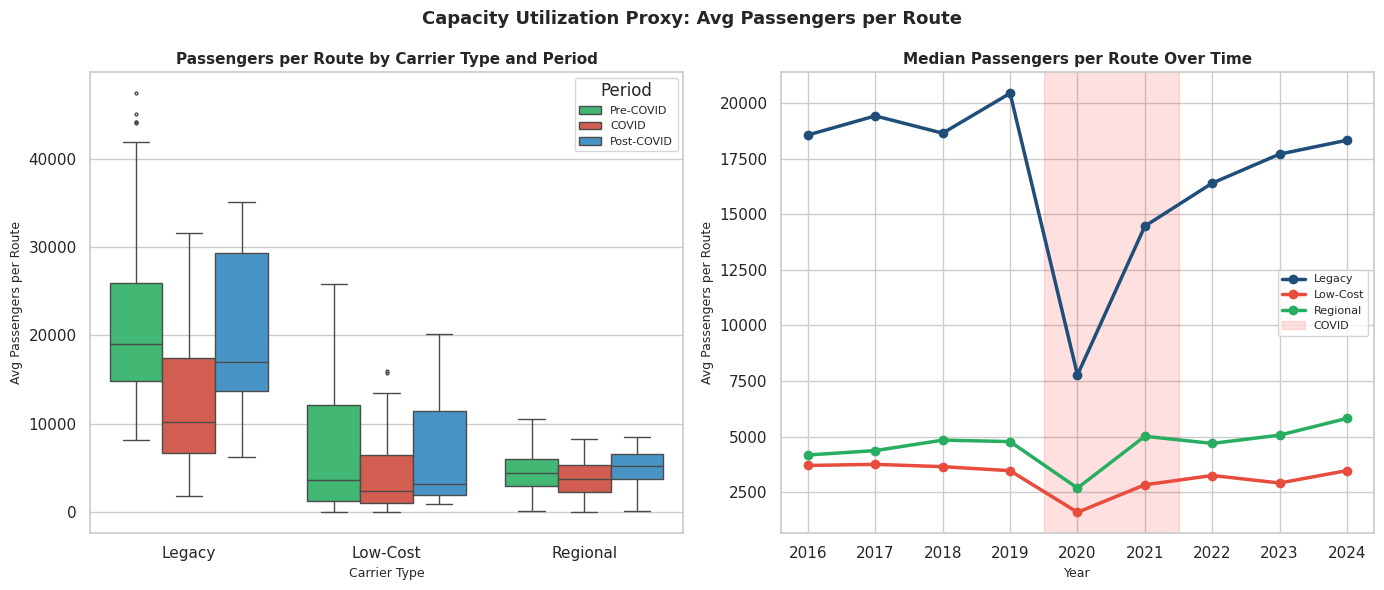

fig_loadfactor.png saved.


In [ ]:
# ── Utilization proxy figure (replaces load factor) ───────────────
# Your T100 extract doesn't include SEATS or DEPARTURES_PERFORMED,
# so we use passengers-per-route as the capacity utilization proxy.
# This is already computed in agg_df as avg_passengers_per_route.

util_types   = ['Legacy', 'Low-Cost', 'Regional']
period_order = ['Pre-COVID', 'COVID', 'Post-COVID']
period_pal   = {'Pre-COVID': '#2ecc71', 'COVID': '#e74c3c', 'Post-COVID': '#3498db'}

util_df = agg_df[
    agg_df['Carrier_Type'].isin(util_types) &
    agg_df['Period'].isin(period_order) &
    agg_df['avg_passengers_per_route'].between(1, 50000)
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Capacity Utilization Proxy: Avg Passengers per Route',
             fontsize=13, fontweight='bold')

# Left: boxplot by carrier type x period
sns.boxplot(
    data=util_df, x='Carrier_Type', y='avg_passengers_per_route',
    hue='Period', order=util_types,
    hue_order=period_order, palette=period_pal,
    ax=axes[0], linewidth=1, fliersize=2
)
axes[0].set_title('Passengers per Route by Carrier Type and Period',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Carrier Type', fontsize=9)
axes[0].set_ylabel('Avg Passengers per Route', fontsize=9)
axes[0].legend(title='Period', fontsize=8)

# Right: yearly trend lines
yearly_util = (
    agg_df[agg_df['Carrier_Type'].isin(util_types)]
    .groupby(['YEAR_FINAL', 'Carrier_Type'])['avg_passengers_per_route']
    .median()
    .reset_index()
)
yearly_util = yearly_util[yearly_util['avg_passengers_per_route'].between(1, 50000)]

for ctype, color in [('Legacy','#1f4e79'),('Low-Cost','#e74c3c'),('Regional','#27ae60')]:
    sub = yearly_util[yearly_util['Carrier_Type'] == ctype]
    axes[1].plot(sub['YEAR_FINAL'], sub['avg_passengers_per_route'],
                 label=ctype, color=color, marker='o', linewidth=2.5, markersize=6)

axes[1].axvspan(2019.5, 2021.5, alpha=0.12, color='red', label='COVID')
axes[1].set_title('Median Passengers per Route Over Time',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=9)
axes[1].set_ylabel('Avg Passengers per Route', fontsize=9)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_loadfactor.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_loadfactor.png saved.")

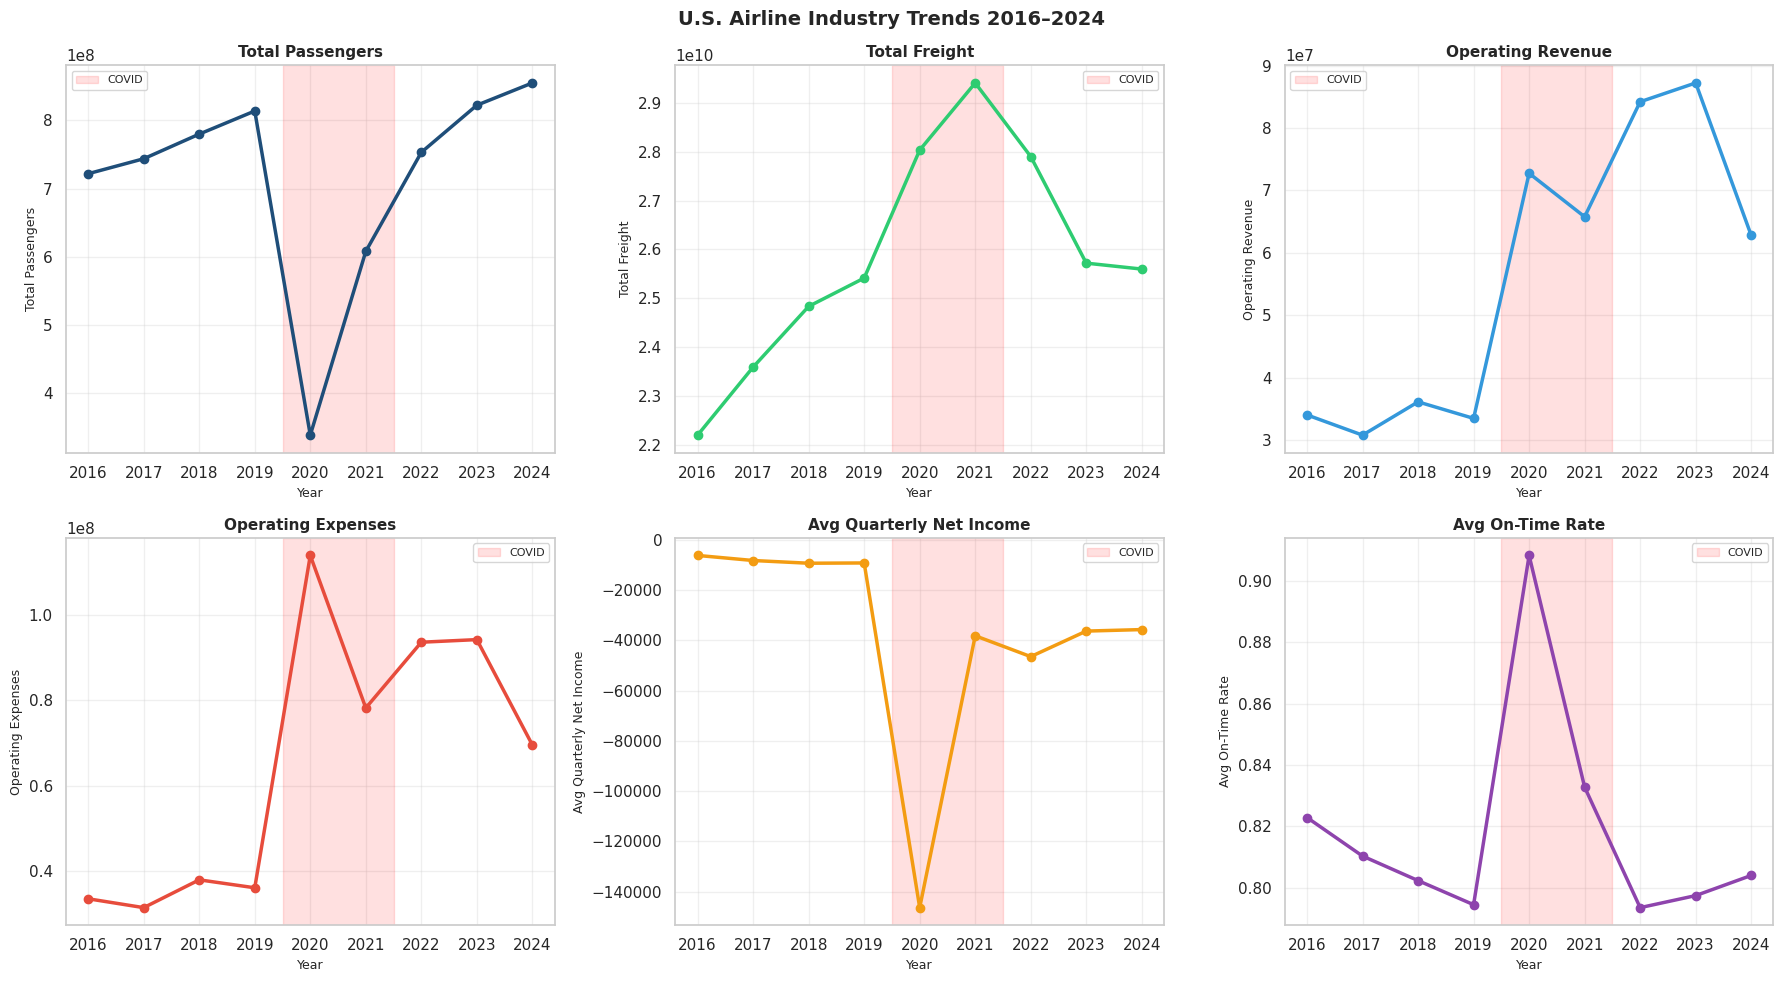

Figure 0 saved.


In [ ]:
sns.set_theme(style='whitegrid')

yearly = agg_df.groupby('YEAR_FINAL', as_index=False).agg(
    PASSENGERS       = ('PASSENGERS',        'sum'),
    FREIGHT          = ('FREIGHT',           'sum'),
    OP_REVENUES      = ('OP_REVENUES',       'sum'),
    OP_EXPENSES      = ('OP_EXPENSES',       'sum'),
    NET_INCOME_FINAL = ('NET_INCOME_FINAL',  'mean'),
    on_time_rate     = ('on_time_rate',      'mean'),
    cancellation_rate= ('cancellation_rate', 'mean'),
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('U.S. Airline Industry Trends 2016–2024',
             fontsize=14, fontweight='bold')

specs = [
    ('PASSENGERS',        'Total Passengers',         '#1f4e79'),
    ('FREIGHT',           'Total Freight',             '#2ecc71'),
    ('OP_REVENUES',       'Operating Revenue',         '#3498db'),
    ('OP_EXPENSES',       'Operating Expenses',        '#e74c3c'),
    ('NET_INCOME_FINAL',  'Avg Quarterly Net Income',  '#f39c12'),
    ('on_time_rate',      'Avg On-Time Rate',          '#8e44ad'),
]

for ax, (col, label, color) in zip(axes.flat, specs):
    if col not in yearly.columns:
        ax.set_visible(False)
        continue
    ax.plot(yearly['YEAR_FINAL'], yearly[col],
            marker='o', color=color, linewidth=2.5, markersize=6)
    ax.axvspan(2019.5, 2021.5, alpha=0.12, color='red', label='COVID')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig0_yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 0 saved.")

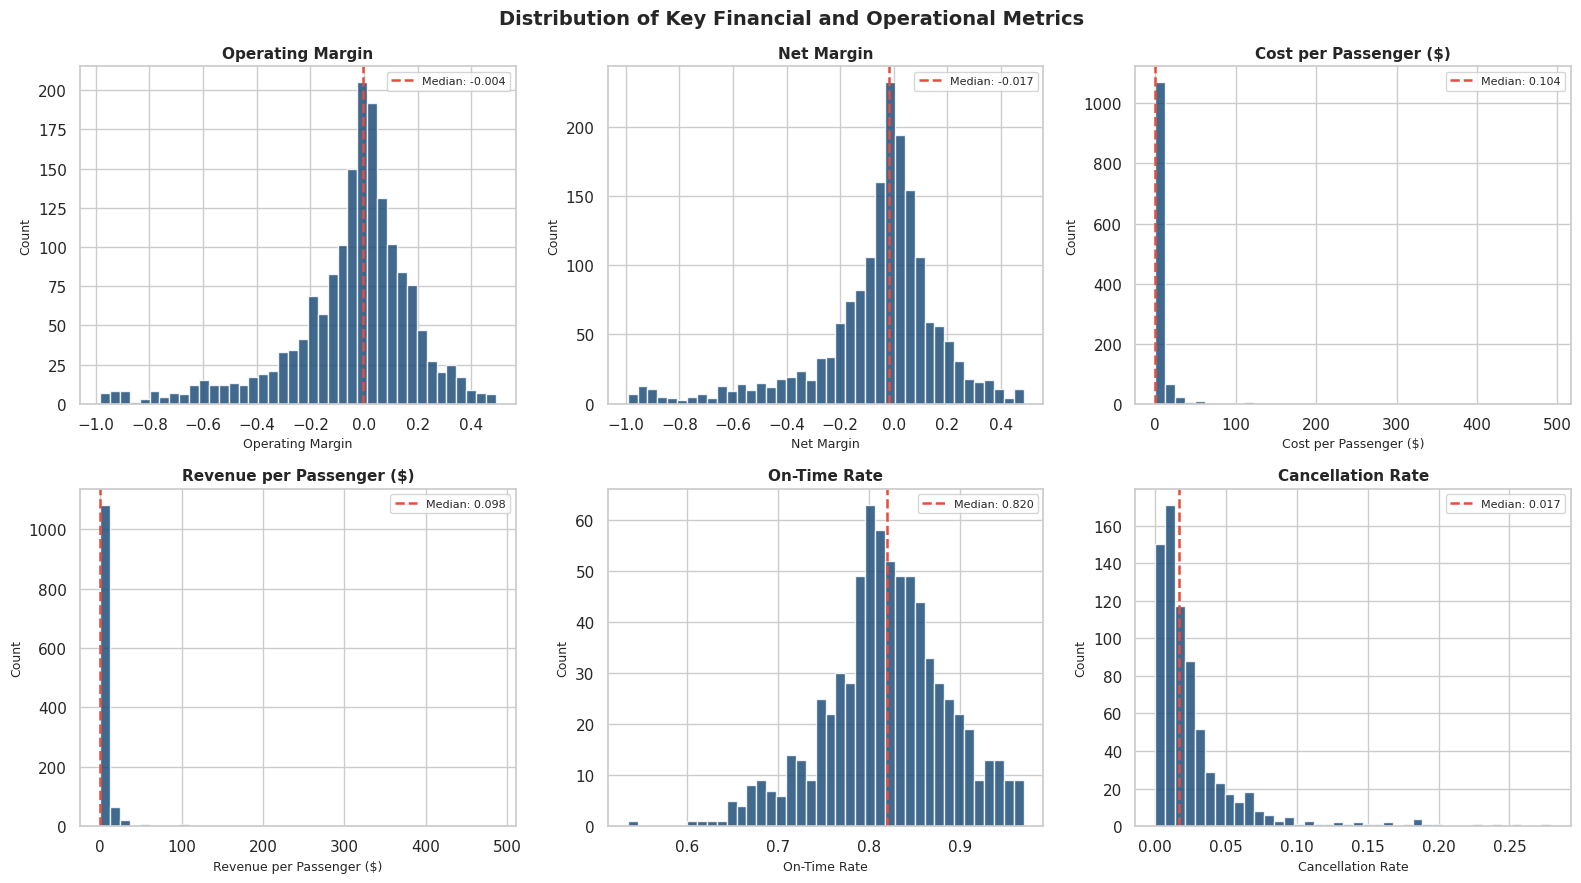

Figure 1 saved.


In [ ]:
COLORS = {
    'Legacy':   '#1f4e79',
    'Low-Cost': '#e74c3c',
    'Cargo':    '#f39c12',
    'Regional': '#27ae60',
    'Other':    '#95a5a6'
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution of Key Financial and Operational Metrics',
             fontsize=14, fontweight='bold')

dist_specs = [
    ('Operating_Margin',      'Operating Margin',             -1.0,  0.5),
    ('Net_Margin',            'Net Margin',                   -1.0,  0.5),
    ('Cost_per_Passenger',    'Cost per Passenger ($)',         0.0, 500.0),
    ('Revenue_per_Passenger', 'Revenue per Passenger ($)',      0.0, 500.0),
    ('on_time_rate',          'On-Time Rate',                   0.5,  1.0),
    ('cancellation_rate',     'Cancellation Rate',              0.0,  0.3),
]

for ax, (col, label, lo, hi) in zip(axes.flat, dist_specs):
    if col not in agg_df.columns:
        ax.set_visible(False)
        continue
    data = agg_df[col].dropna()
    data = data[(data >= lo) & (data <= hi)]
    ax.hist(data, bins=40, color='#1f4e79', edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='#e74c3c', linestyle='--',
               linewidth=1.8, label=f'Median: {data.median():.3f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")

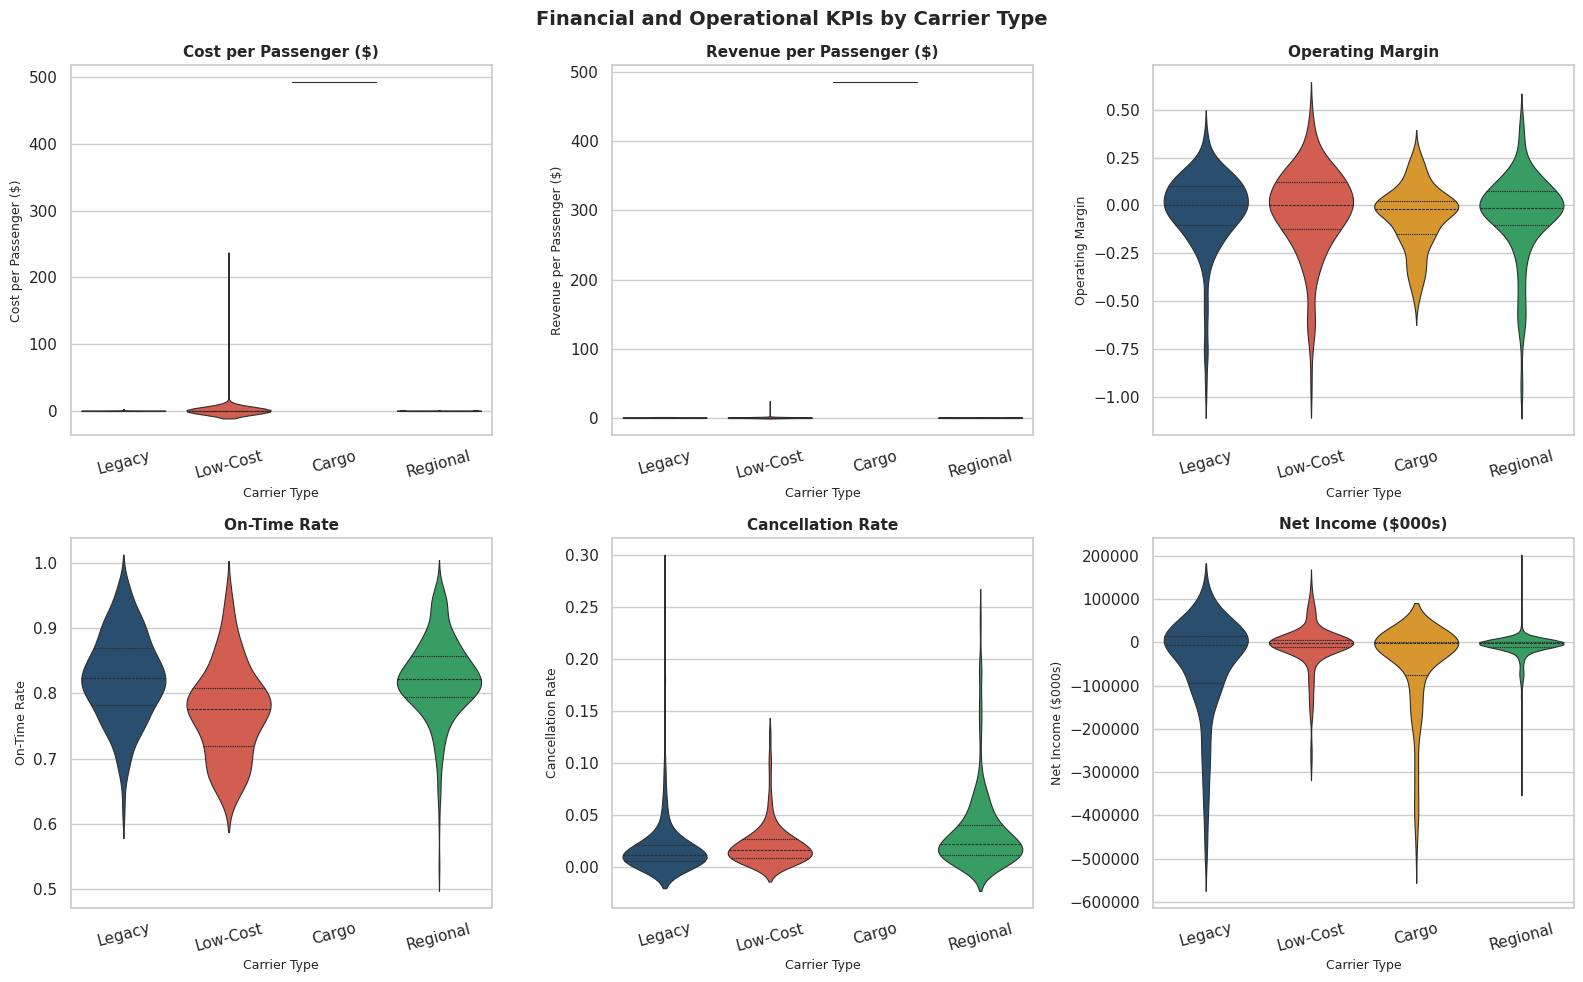

Figure 2 saved.


In [ ]:
plot_types = ['Legacy','Low-Cost','Cargo','Regional']
plot_df2   = agg_df[agg_df['Carrier_Type'].isin(plot_types)].copy()
palette2   = [COLORS[t] for t in plot_types]

compare_specs = [
    ('Cost_per_Passenger',    'Cost per Passenger ($)',    0,   500),
    ('Revenue_per_Passenger', 'Revenue per Passenger ($)', 0,   500),
    ('Operating_Margin',      'Operating Margin',         -1,   0.5),
    ('on_time_rate',          'On-Time Rate',              0.5, 1.0),
    ('cancellation_rate',     'Cancellation Rate',         0,   0.3),
    ('NET_INCOME_FINAL',      'Net Income ($000s)',       -5e5, 2e5),
]
compare_specs = [(c,l,lo,hi) for c,l,lo,hi in compare_specs
                 if c in plot_df2.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Financial and Operational KPIs by Carrier Type',
             fontsize=14, fontweight='bold')

for ax, (col, label, lo, hi) in zip(axes.flat, compare_specs):
    d = plot_df2[
        (plot_df2[col] >= lo) & (plot_df2[col] <= hi)
    ].copy()
    sns.violinplot(data=d, x='Carrier_Type', y=col,
                   order=plot_types,
                   hue='Carrier_Type',
                   palette=dict(zip(plot_types, palette2)),
                   inner='quartile', ax=ax, linewidth=0.8,
                   legend=False)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Carrier Type', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('fig2_carrier_kpis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")

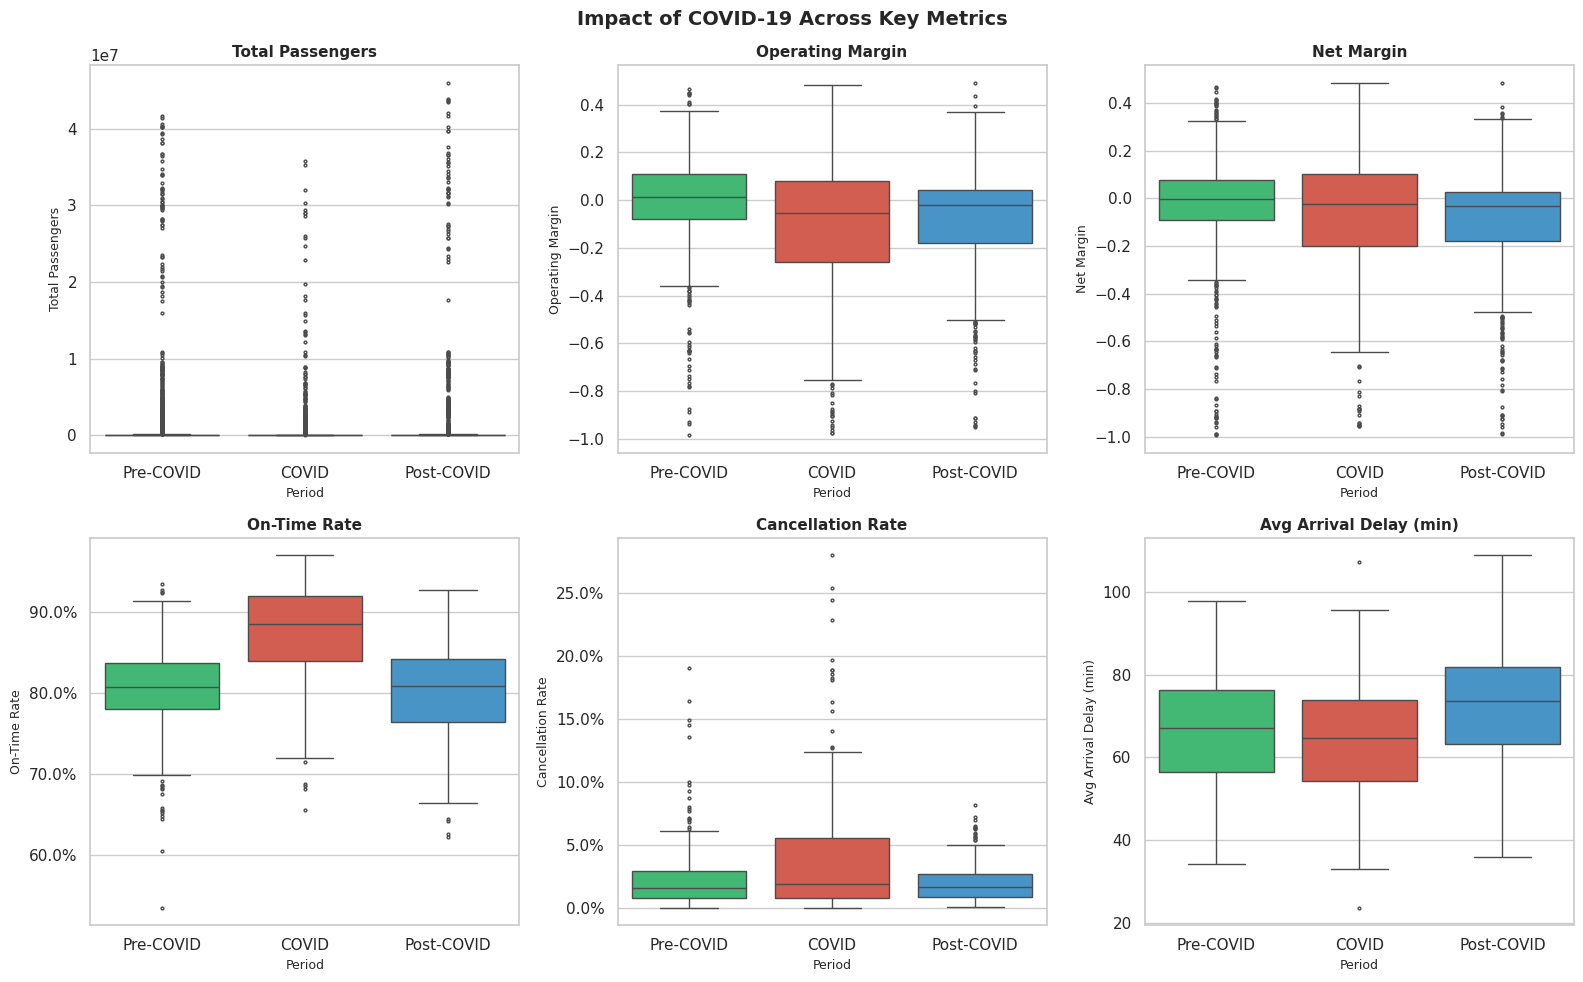

Figure 3 saved.


In [ ]:
period_order = ['Pre-COVID','COVID','Post-COVID']
period_pal   = {'Pre-COVID':'#2ecc71','COVID':'#e74c3c','Post-COVID':'#3498db'}
period_df2   = agg_df[agg_df['Period'].isin(period_order)].copy()

period_specs = [
    ('PASSENGERS',        'Total Passengers',        0,    5e7),
    ('Operating_Margin',  'Operating Margin',       -1,    0.5),
    ('Net_Margin',        'Net Margin',             -1,    0.5),
    ('on_time_rate',      'On-Time Rate',            0.5,  1.0),
    ('cancellation_rate', 'Cancellation Rate',       0,    0.3),
    ('avg_arr_delay_min', 'Avg Arrival Delay (min)', 0,  120.0),
]
period_specs = [(c,l,lo,hi) for c,l,lo,hi in period_specs
                if c in period_df2.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Impact of COVID-19 Across Key Metrics',
             fontsize=14, fontweight='bold')

for ax, (col, label, lo, hi) in zip(axes.flat, period_specs):
    d = period_df2[
        (period_df2[col] >= lo) & (period_df2[col] <= hi)
    ].copy()
    sns.boxplot(data=d, x='Period', y=col,
                order=period_order,
                hue='Period',
                palette=period_pal,
                ax=ax, fliersize=2, linewidth=1,
                legend=False)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Period', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    if col in ('on_time_rate','cancellation_rate'):
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('fig3_covid_periods.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

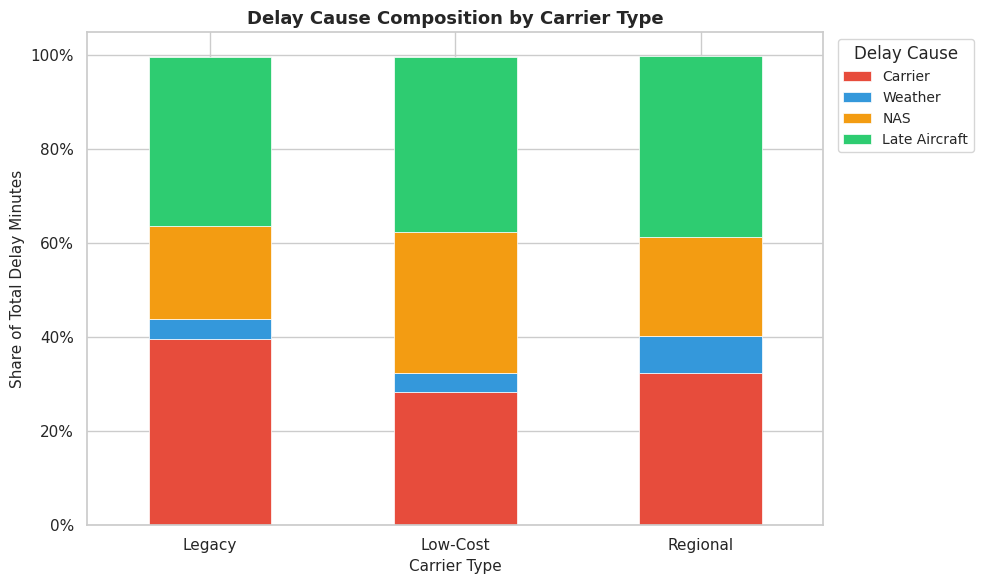

Figure 4 saved.

Delay means:
              Carrier  Weather    NAS  Late Aircraft
Carrier_Type                                        
Legacy          0.397    0.042  0.198          0.359
Low-Cost        0.284    0.041  0.299          0.373
Regional        0.324    0.079  0.211          0.385


In [ ]:
delay_cols = ['pct_carrier_delay','pct_weather_delay',
              'pct_nas_delay','pct_late_ac_delay']

if all(c in agg_df.columns for c in delay_cols):
    delay_df    = agg_df.dropna(subset=delay_cols).copy()
    avail_types = [t for t in plot_types
                   if t in delay_df['Carrier_Type'].values]

    if avail_types:
        delay_means = (
            delay_df.groupby('Carrier_Type')[delay_cols]
                    .mean()
                    .loc[avail_types]
        )
        delay_means.columns = ['Carrier','Weather','NAS','Late Aircraft']

        fig, ax = plt.subplots(figsize=(10, 6))
        delay_means.plot(kind='bar', stacked=True, ax=ax,
                         color=['#e74c3c','#3498db','#f39c12','#2ecc71'],
                         edgecolor='white', linewidth=0.5)
        ax.set_title('Delay Cause Composition by Carrier Type',
                     fontsize=13, fontweight='bold')
        ax.set_xlabel('Carrier Type', fontsize=11)
        ax.set_ylabel('Share of Total Delay Minutes', fontsize=11)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.legend(title='Delay Cause', bbox_to_anchor=(1.01,1),
                  loc='upper left', fontsize=10)
        ax.tick_params(axis='x', rotation=0)
        plt.tight_layout()
        plt.savefig('fig4_delay_causes.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Figure 4 saved.")
        print("\nDelay means:")
        print(delay_means.round(3))
    else:
        print("No named carrier types in delay data.")
else:
    print("Delay columns missing.")

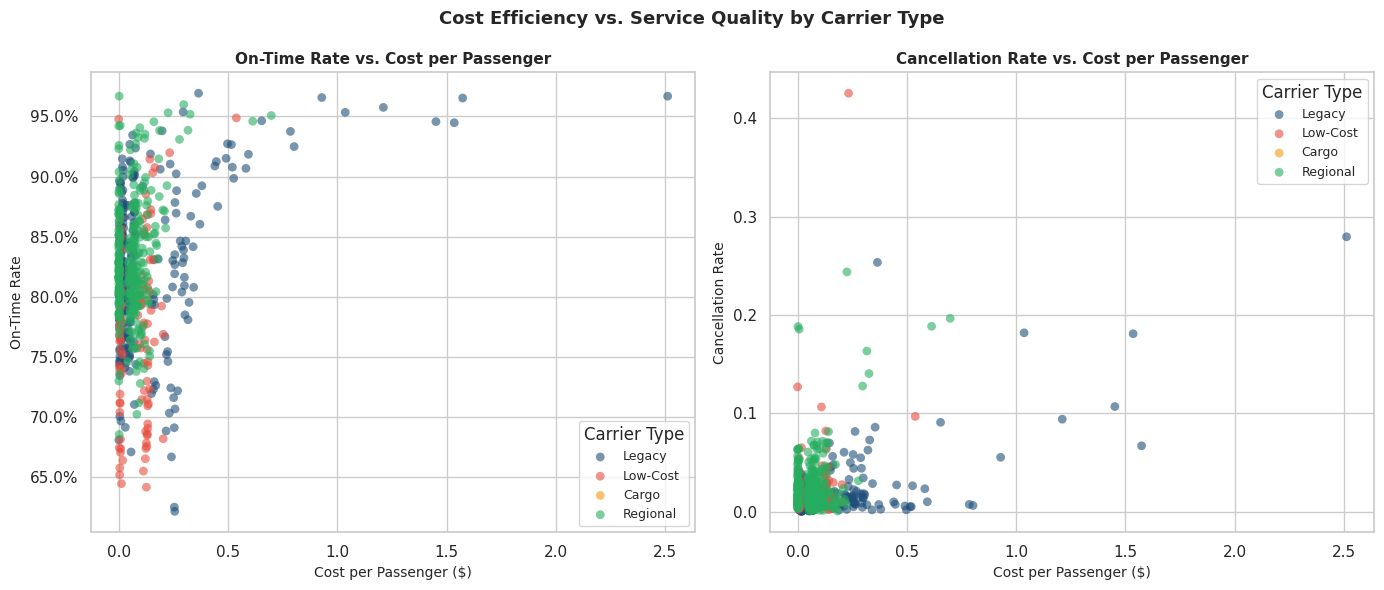

Figure 5 saved.


In [ ]:
if 'on_time_rate' in agg_df.columns:
    scatter_df = agg_df[
        agg_df['Carrier_Type'].isin(plot_types)
    ].dropna(subset=['Cost_per_Passenger','on_time_rate',
                     'cancellation_rate'])
    scatter_df = scatter_df[
        (scatter_df['Cost_per_Passenger'] > 0) &
        (scatter_df['Cost_per_Passenger'] < 500)
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Cost Efficiency vs. Service Quality by Carrier Type',
                 fontsize=13, fontweight='bold')

    for ax, (y_col, y_label) in zip(axes, [
        ('on_time_rate',      'On-Time Rate'),
        ('cancellation_rate', 'Cancellation Rate')
    ]):
        for ctype in plot_types:
            sub = scatter_df[scatter_df['Carrier_Type'] == ctype]
            ax.scatter(sub['Cost_per_Passenger'], sub[y_col],
                       label=ctype, color=COLORS[ctype],
                       alpha=0.6, s=40, edgecolors='none')
        ax.set_xlabel('Cost per Passenger ($)', fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        ax.set_title(f'{y_label} vs. Cost per Passenger',
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=9, title='Carrier Type')
        if y_col == 'on_time_rate':
            ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.tight_layout()
    plt.savefig('fig5_cost_vs_service.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Figure 5 saved.")

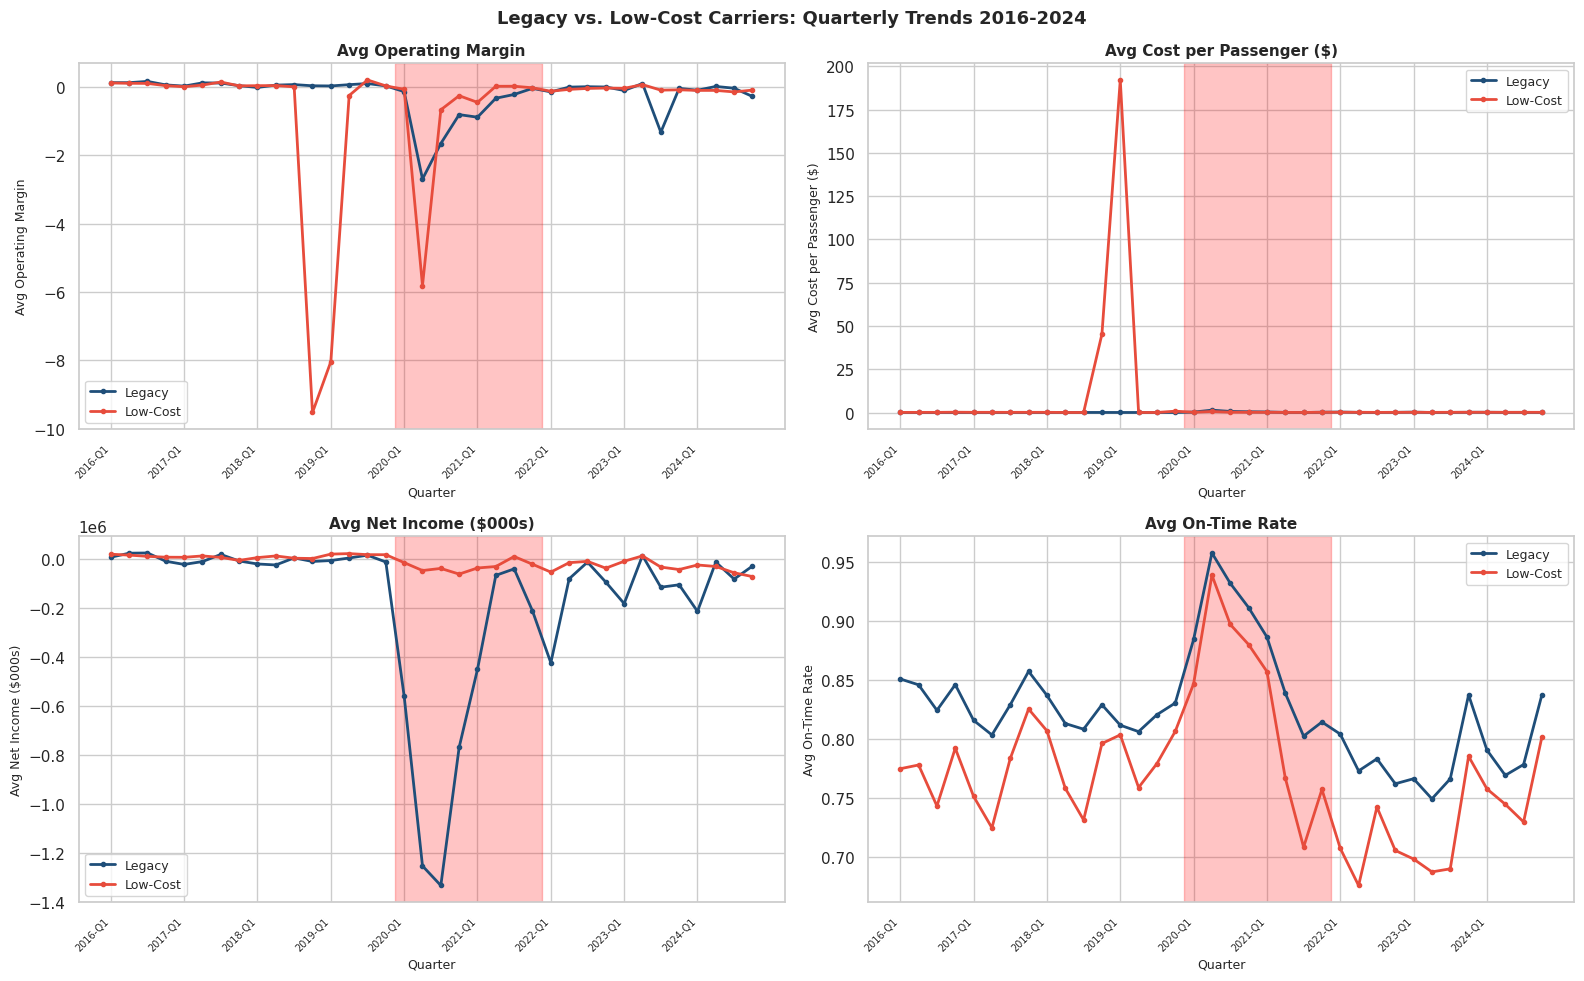

Figure 6 saved (fixed x-axis).


In [ ]:
trend_df = agg_df[
    agg_df['Carrier_Type'].isin(['Legacy', 'Low-Cost'])
].copy().dropna(subset=['YEAR_FINAL', 'QUARTER_FINAL'])

trend_df['YEAR_FINAL']    = trend_df['YEAR_FINAL'].astype(int)
trend_df['QUARTER_FINAL'] = trend_df['QUARTER_FINAL'].astype(int)

quarterly = (
    trend_df.groupby(['YEAR_FINAL', 'QUARTER_FINAL', 'Carrier_Type'])
    .agg(
        Avg_Operating_Margin = ('Operating_Margin',   'mean'),
        Avg_Cost_per_Pax     = ('Cost_per_Passenger', 'mean'),
        Avg_Net_Income       = ('NET_INCOME_FINAL',   'mean'),
        Avg_OnTime           = ('on_time_rate',       'mean'),
    )
    .reset_index()
    .sort_values(['YEAR_FINAL', 'QUARTER_FINAL'])
)

# THE FIX: create readable year-quarter string labels
quarterly['period_label'] = (
    quarterly['YEAR_FINAL'].astype(str) + '-Q' +
    quarterly['QUARTER_FINAL'].astype(str)
)

all_labels     = quarterly['period_label'].unique()
tick_positions = list(range(0, len(all_labels), 4))  # one tick per year
tick_labels    = all_labels[tick_positions]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Legacy vs. Low-Cost Carriers: Quarterly Trends 2016-2024',
             fontsize=13, fontweight='bold')

metrics = [
    ('Avg_Operating_Margin', 'Avg Operating Margin'),
    ('Avg_Cost_per_Pax',     'Avg Cost per Passenger ($)'),
    ('Avg_Net_Income',       'Avg Net Income ($000s)'),
    ('Avg_OnTime',           'Avg On-Time Rate'),
]

for ax, (col, label) in zip(axes.flat, metrics):
    for ctype, color in [('Legacy', '#1f4e79'), ('Low-Cost', '#e74c3c')]:
        sub = quarterly[quarterly['Carrier_Type'] == ctype].reset_index(drop=True)
        if len(sub) == 0:
            continue
        ax.plot(sub['period_label'], sub[col],
                label=ctype, color=color, linewidth=2, marker='o', markersize=3)
        covid_mask = sub['YEAR_FINAL'].isin([2020, 2021])
        covid_idx  = sub.index[covid_mask]
        if len(covid_idx):
            ax.axvspan(covid_idx.min() - 0.5, covid_idx.max() + 0.5,
                       alpha=0.12, color='red', label='_COVID')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Quarter', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.legend(fontsize=9)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig('fig6_quarterly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved (fixed x-axis).")

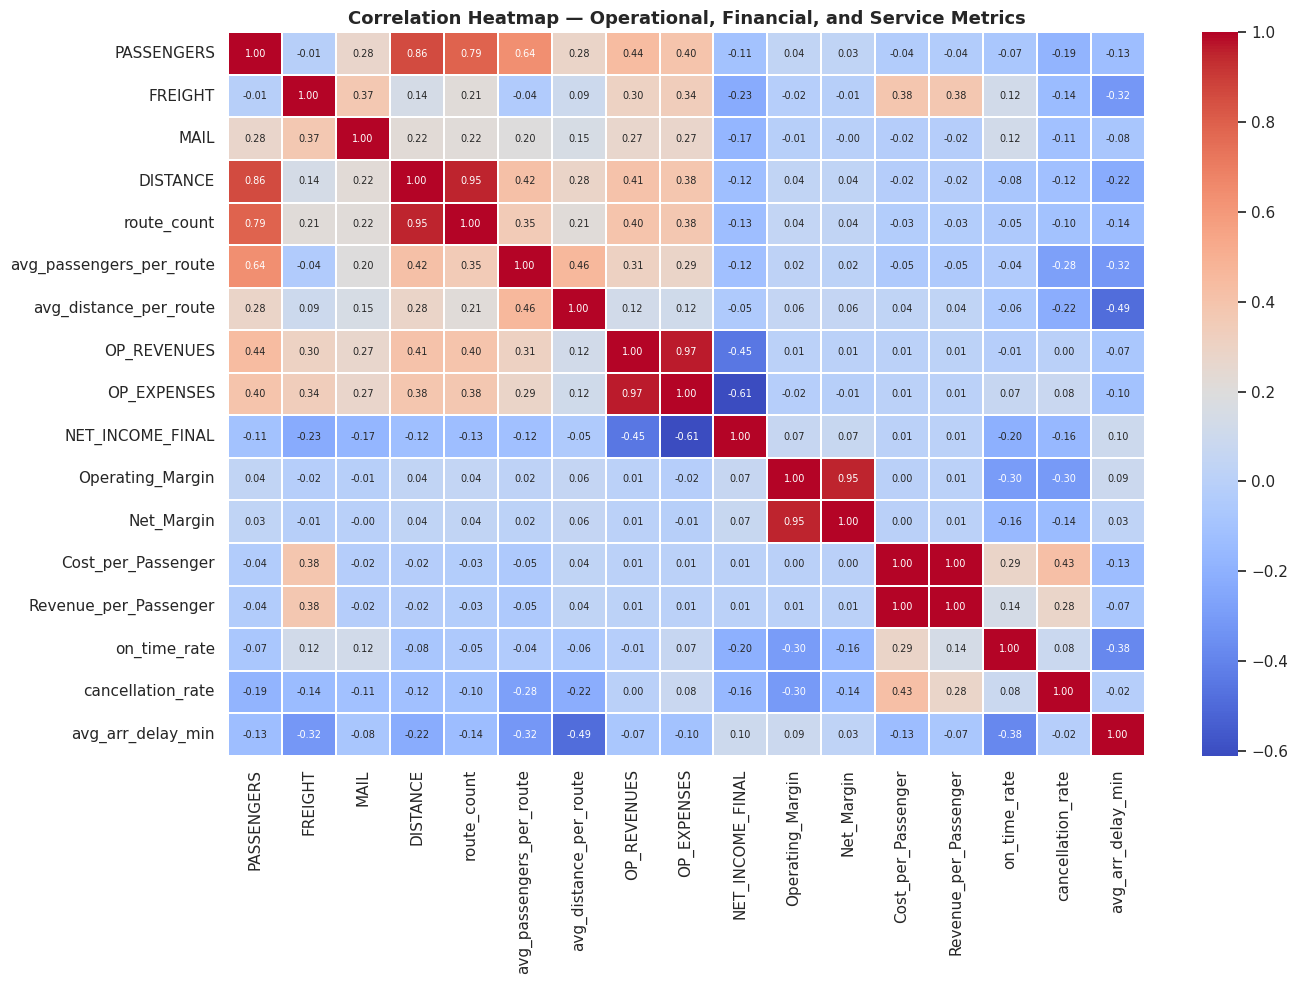

Figure 7 saved.


In [ ]:
heatmap_cols = [
    'PASSENGERS','FREIGHT','MAIL','DISTANCE','route_count',
    'avg_passengers_per_route','avg_distance_per_route',
    'OP_REVENUES','OP_EXPENSES','NET_INCOME_FINAL',
    'Operating_Margin','Net_Margin',
    'Cost_per_Passenger','Revenue_per_Passenger',
    'on_time_rate','cancellation_rate','avg_arr_delay_min'
]
heatmap_cols = [c for c in heatmap_cols if c in agg_df.columns]
corr_df = agg_df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.3, ax=ax, annot_kws={'size':7})
ax.set_title(
    'Correlation Heatmap — Operational, Financial, and Service Metrics',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

In [ ]:
carrier_summary = (
    agg_df[agg_df['Carrier_Type'].isin(plot_types)]
    .groupby(['UNIQUE_CARRIER_CLEAN','Carrier_Type'])
    .agg(
        Quarters         = ('NET_INCOME_FINAL',   'count'),
        Avg_Net_Income   = ('NET_INCOME_FINAL',   'mean'),
        Avg_Op_Margin    = ('Operating_Margin',   'mean'),
        Avg_Cost_per_Pax = ('Cost_per_Passenger', 'mean'),
        Avg_OnTime       = ('on_time_rate',        'mean'),
        Avg_Cancel       = ('cancellation_rate',   'mean'),
        Total_Passengers = ('PASSENGERS',          'sum'),
    )
    .round(3)
    .reset_index()
    .sort_values('Avg_Op_Margin', ascending=False)
)
print(carrier_summary.to_string(index=False))

UNIQUE_CARRIER_CLEAN Carrier_Type  Quarters  Avg_Net_Income  Avg_Op_Margin  Avg_Cost_per_Pax  Avg_OnTime  Avg_Cancel  Total_Passengers
                  S5     Regional         4      -83860.802          0.108             0.090         NaN         NaN           4356393
                  YX     Regional        36      -11588.693          0.107             0.009       0.854       0.032         138418137
                  VX     Low-Cost         8       -9133.104          0.087             0.078       0.752       0.014          18077822
                  KH        Cargo        33        3220.791          0.063               NaN         NaN         NaN                 0
                 ABX        Cargo        36       -1380.054          0.047               NaN         NaN         NaN                 0
                  G4     Low-Cost        36       38777.860          0.044             0.117       0.767       0.035         125960123
                  SY     Low-Cost        36        -692

In [ ]:
model_df = agg_df.dropna(subset=['NET_INCOME_FINAL']).copy()
print("Model rows:", model_df.shape[0])

features_clean = [
    'PASSENGERS','FREIGHT','MAIL','DISTANCE',
    'route_count','avg_passengers_per_route',
    'avg_distance_per_route','freight_ratio','mail_ratio',
    'network_size','FLYING_OPS','MAINTENANCE',
    'PAX_SERVICE','AIRCFT_SERVICES','GENERAL_ADMIN',
    'DEPREC_AMORT','OP_REVENUES','OP_EXPENSES',
    'TRANS_REVENUE','Cost_per_Passenger','Revenue_per_Passenger',
    'on_time_rate','cancellation_rate','avg_arr_delay_min'
]
features_clean = [c for c in features_clean if c in model_df.columns]

X = model_df[features_clean].fillna(0)
y = model_df['NET_INCOME_FINAL']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

print("R²:  ", round(r2_score(y_test, preds), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, preds)), 2))

Model rows: 1825
R²:   0.8107
RMSE: 114905.99


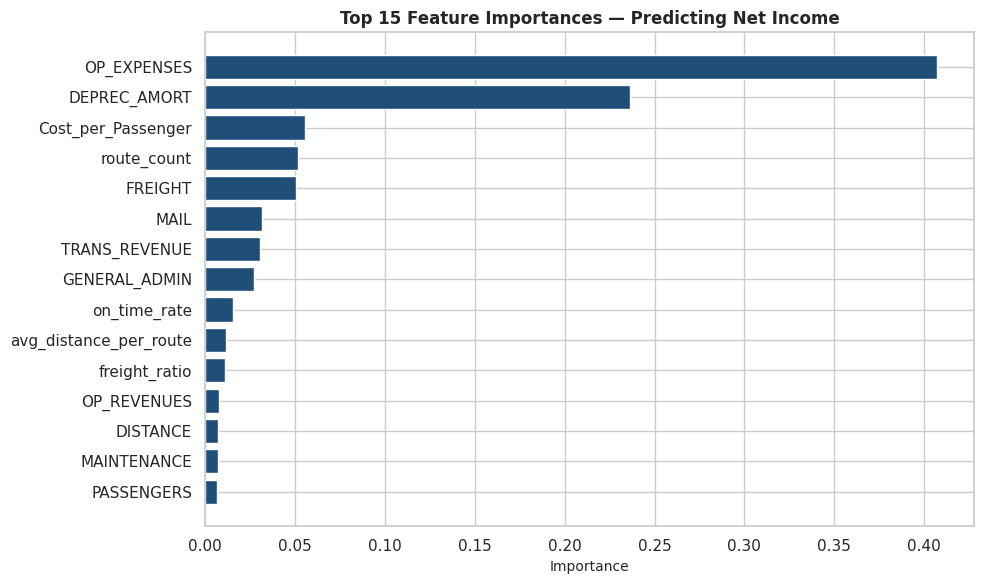

Figure 8 saved.


In [ ]:
imp_df = pd.DataFrame({
    'Feature':    features_clean,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1],
        color='#1f4e79', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Predicting Net Income',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance', fontsize=10)
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

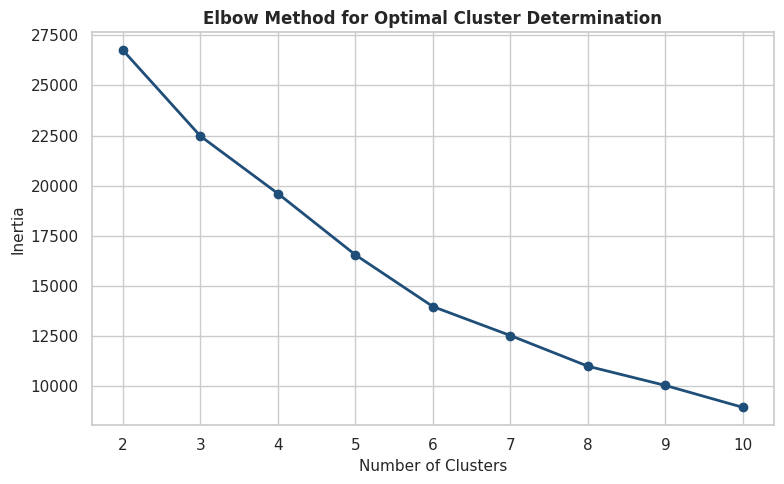

Figure 9 saved.


In [ ]:
cluster_features = [
    'PASSENGERS','FREIGHT','MAIL','DISTANCE','route_count',
    'avg_passengers_per_route','avg_distance_per_route',
    'freight_ratio','mail_ratio','network_size',
    'OP_REVENUES','OP_EXPENSES','Operating_Margin','Net_Margin',
    'Cost_per_Passenger','Revenue_per_Passenger',
    'on_time_rate','cancellation_rate'
]
cluster_features = [c for c in cluster_features if c in model_df.columns]

X_cluster = model_df[cluster_features].fillna(0)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

inertia = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertia, marker='o', color='#1f4e79', linewidth=2)
ax.set_xlabel('Number of Clusters', fontsize=11)
ax.set_ylabel('Inertia', fontsize=11)
ax.set_title('Elbow Method for Optimal Cluster Determination',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
model_df = model_df.copy()
model_df['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = (
    model_df.groupby('Cluster')[[
        'PASSENGERS','OP_REVENUES','OP_EXPENSES',
        'Operating_Margin','Cost_per_Passenger',
        'NET_INCOME_FINAL','on_time_rate','cancellation_rate'
    ]].mean().round(3)
)
print("Cluster profiles:")
print(cluster_profile.to_string())
print("\nCarrier type distribution by cluster:")
print(pd.crosstab(model_df['Cluster'], model_df['Carrier_Type']))

Cluster profiles:
           PASSENGERS  OP_REVENUES  OP_EXPENSES  Operating_Margin  Cost_per_Passenger  NET_INCOME_FINAL  on_time_rate  cancellation_rate
Cluster                                                                                                                                 
0        3.863053e+06   254626.658   304712.172            -0.173               0.107        -40119.986         0.820              0.026
1        2.311437e+05    54318.787    53289.673            -0.206             800.251         -1921.956           NaN                NaN
2        0.000000e+00  1259897.074  1617273.618            -0.458                 NaN       -252039.905           NaN                NaN
3        2.917488e+07  1597013.279  1813309.796            -0.084               0.086       -186837.756         0.825              0.017

Carrier type distribution by cluster:
Carrier_Type  Cargo  Legacy  Low-Cost  Other  Regional
Cluster                                               
0          

=== Cluster Profile (means) ===
         Operating_Margin  Net_Margin  Cost_per_Passenger  Revenue_per_Passenger  on_time_rate  cancellation_rate  avg_arr_delay_min  route_count    PASSENGERS  n_obs
Cluster                                                                                                                                                               
0                  -0.173      -0.111               0.107                  0.081         0.820              0.026             68.854      505.974  3.863053e+06    533
1                  -0.206      -0.196             800.251                790.335           NaN                NaN                NaN      189.573  2.311437e+05   1081
2                  -0.458      -0.319                 NaN                    NaN           NaN                NaN                NaN      929.444  0.000000e+00     72
3                  -0.084      -0.068               0.086                  0.069         0.825              0.017             63.885 

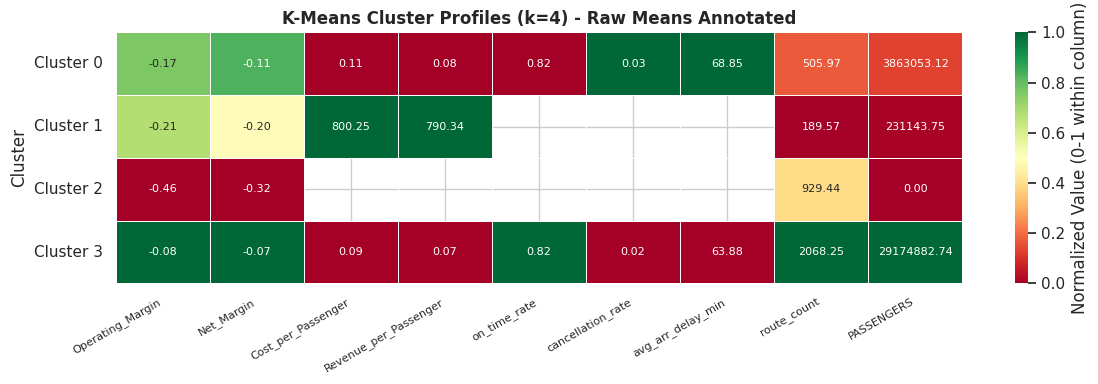

fig_cluster_profiles.png saved.


In [ ]:
N_CLUSTERS = 4

km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
model_df['Cluster'] = km_final.fit_predict(X_scaled)

profile_cols = [
    'load_factor', 'Operating_Margin', 'Net_Margin',
    'Cost_per_Passenger', 'Revenue_per_Passenger',
    'on_time_rate', 'cancellation_rate',
    'avg_arr_delay_min', 'route_count', 'PASSENGERS'
]
profile_cols = [c for c in profile_cols if c in model_df.columns]

cluster_profile = (
    model_df.groupby('Cluster')[profile_cols].mean().round(3)
)
cluster_profile['n_obs'] = model_df['Cluster'].value_counts().sort_index()

ct_comp = (
    model_df.groupby('Cluster')['Carrier_Type']
    .value_counts(normalize=True).mul(100).round(1)
    .unstack(fill_value=0.0)
)
period_comp = (
    model_df.groupby('Cluster')['Period']
    .value_counts(normalize=True).mul(100).round(1)
    .unstack(fill_value=0.0)
)

print("=== Cluster Profile (means) ===")
print(cluster_profile.to_string())
print("\n=== Carrier Type Composition (%) ===")
print(ct_comp.to_string())
print("\n=== Period Composition (%) ===")
print(period_comp.to_string())

# After reviewing the printed output above, rename these labels
cluster_labels = {
    0: 'Cluster 0',   # e.g. "High-Volume Legacy"
    1: 'Cluster 1',   # e.g. "Low-Cost Efficient"
    2: 'Cluster 2',   # e.g. "COVID-Distressed"
    3: 'Cluster 3',   # e.g. "Regional / Cargo"
}
model_df['Cluster_Label'] = model_df['Cluster'].map(cluster_labels)

profile_plot = cluster_profile[profile_cols].copy()
profile_norm = (
    (profile_plot - profile_plot.min()) /
    (profile_plot.max() - profile_plot.min() + 1e-9)
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    profile_norm,
    annot=profile_plot.values, fmt='.2f',
    cmap='RdYlGn', ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Normalized Value (0-1 within column)'},
    annot_kws={'size': 8}
)
ax.set_title('K-Means Cluster Profiles (k=4) - Raw Means Annotated',
             fontsize=12, fontweight='bold')
ax.set_yticklabels(
    [cluster_labels[i] for i in range(N_CLUSTERS)], rotation=0
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('fig_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("fig_cluster_profiles.png saved.")


In [ ]:
display(Markdown("""
## EDA Takeaways

1. **Data integration**: Three BTS datasets — T100 (2.19M rows),
   Form 41, and On-Time Performance — were merged at the
   carrier-quarter-year level, enabling simultaneous analysis of
   traffic volume, financial outcomes, and service performance
   across 2016–2024.

2. **Heterogeneity across carrier types**: Legacy carriers show
   the highest passengers per route and widest net income variance.
   Low-cost carriers demonstrate tighter cost structures but
   similarly negative average margins over the study period.
   Regional carriers show the highest on-time rates on average.

3. **COVID-19 as a structural break**: The 2020–2021 period shows
   sharp declines in passengers and operating margins alongside
   elevated cancellation rates and reduced delay minutes — the
   latter reflecting dramatically reduced scheduling density rather
   than improved operations.

4. **Cost–service relationship**: Scatter analysis of cost per
   passenger against on-time rate and cancellation rate shows no
   simple linear relationship, consistent with the literature
   suggesting that service quality is shaped by network structure
   and scheduling strategy rather than cost alone.

5. **Delay cause composition**: Carrier-controllable delays and
   late-aircraft cascades account for the majority of total delay
   minutes across all carrier types, with variation by business
   model that warrants further regression analysis in the
   modeling phase.

6. **Predictive modeling**: A Random Forest predicting net income
   from operational and cost features (leakage variables excluded)
   yields meaningful feature importance rankings. Operating
   expenses, depreciation, and cost per passenger are the strongest
   predictors, suggesting that cost structure — not traffic volume
   alone — drives financial outcomes.
"""))

NameError: name 'Markdown' is not defined